# Challenge sur la Fraude

## Chargements des bibliothèques et des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "6"  # Définition d'un nombre de process pour éviter les warning
os.listdir() #listing des fichiers pour chargements

['.ipynb_checkpoints',
 'catboost_info',
 'cat_fraud.xlsx',
 'Challenge_Fraude - Copie.ipynb',
 'Challenge_Fraude-Copy1.ipynb',
 'Challenge_Fraude.ipynb',
 'challengfe submission.csv',
 'df_feature.csv',
 'fraude.pdf',
 'fraude.pptx',
 'submission.csv',
 'Untitled.ipynb',
 'X_test_8skS2ey.csv',
 'X_train_G3tdtEn.csv',
 'Y_test_random_2.csv',
 'Y_train_2_XPXJDyy.csv',
 '~$fraud.pptx',
 '~$fraude.pptx']

In [3]:
#Paramètre permettant de consulter l'ensemble des colonnes et adapter le contenu des colonnes sans tronquer
pd.set_option("display.max_colwidth",None)
pd.set_option('display.max_columns', None)

In [4]:
#Chargement des jeux d'entrainement X_train, X_test
X_train=pd.read_csv("X_train_G3tdtEn.csv", low_memory=False)#Ajustement mémoire
y_train=pd.read_csv("Y_train_2_XPXJDyy.csv", index_col=0)#Suppression colonnes lors de l'intégration


In [5]:
#Chargement du jeu de test
X_test=pd.read_csv("X_test_8skS2ey.csv", low_memory=False)

## Analyse exploratoire des données

In [6]:
print(f"Composition des jeux de données pour X_train de {X_train.shape[0]} lignes et de {X_train.shape[1]} colonnes")
print(f"Composition des jeux de données pour y_train de {y_train.shape[0]} lignes et de {y_train.shape[1]} colonnes")

Composition des jeux de données pour X_train de 92790 lignes et de 146 colonnes
Composition des jeux de données pour y_train de 92790 lignes et de 2 colonnes


In [7]:
print(f"Composition des jeux de données pour X_test de {X_test.shape[0]} lignes et de {X_test.shape[1]} colonnes")

Composition des jeux de données pour X_test de 23198 lignes et de 146 colonnes


In [8]:
X_train.head(3)

,ID,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,item11,item12,item13,item14,item15,item16,item17,item18,item19,item20,item21,item22,item23,item24,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,cash_price11,cash_price12,cash_price13,cash_price14,cash_price15,cash_price16,cash_price17,cash_price18,cash_price19,cash_price20,cash_price21,cash_price22,cash_price23,cash_price24,make1,make2,make3,make4,make5,make6,make7,make8,make9,make10,make11,make12,make13,make14,make15,make16,make17,make18,make19,make20,make21,make22,make23,make24,model1,model2,model3,model4,model5,model6,model7,model8,model9,model10,model11,model12,model13,model14,model15,model16,model17,model18,model19,model20,model21,model22,model23,model24,goods_code1,goods_code2,goods_code3,goods_code4,goods_code5,goods_code6,goods_code7,goods_code8,goods_code9,goods_code10,goods_code11,goods_code12,goods_code13,goods_code14,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24,Nbr_of_prod_purchas1,Nbr_of_prod_purchas2,Nbr_of_prod_purchas3,Nbr_of_prod_purchas4,Nbr_of_prod_purchas5,Nbr_of_prod_purchas6,Nbr_of_prod_purchas7,Nbr_of_prod_purchas8,Nbr_of_prod_purchas9,Nbr_of_prod_purchas10,Nbr_of_prod_purchas11,Nbr_of_prod_purchas12,Nbr_of_prod_purchas13,Nbr_of_prod_purchas14,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,Nb_of_items
0,85517,COMPUTERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,889.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020 APPLE MACBOOK AIR 13 3 RETINA DISPLAY M1 PROC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239246776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,51113,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,409.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE WATCH SERIES 6 GPS 44MM SPACE GREY ALUMINIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239001518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,83008,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG QE75Q70A 2021 QLED HDR 4K ULTRA HD SMART T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239842093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [9]:
X_train.dtypes

ID                         int64
item1                        str
item2                        str
item3                        str
item4                        str
                          ...   
Nbr_of_prod_purchas21    float64
Nbr_of_prod_purchas22    float64
Nbr_of_prod_purchas23    float64
Nbr_of_prod_purchas24    float64
Nb_of_items              float64
Length: 146, dtype: object

In [10]:
X_train.iloc[:,5].value_counts()

item5
FULFILMENT CHARGE          388
BED LINEN                  220
LIVING DINING FURNITURE    166
BEDROOM FURNITURE          152
LIGHTING                   106
                          ... 
SCHOOLWEAR                   1
PARTY DECORATIONS            1
LAUNDRY & CLOTHESCARE        1
FITTED KITCHENS              1
WOMENS FOOTWEAR              1
Name: count, Length: 107, dtype: int64

In [11]:
X_train.isnull().sum()

ID                           0
item1                        0
item2                    48134
item3                    79889
item4                    88228
                         ...  
Nbr_of_prod_purchas21    92713
Nbr_of_prod_purchas22    92727
Nbr_of_prod_purchas23    92740
Nbr_of_prod_purchas24    92747
Nb_of_items                  0
Length: 146, dtype: int64

In [12]:
y_train.columns

Index(['ID', 'fraud_flag'], dtype='str')

In [13]:
y_train.iloc[:,1].value_counts()

fraud_flag
0    91471
1     1319
Name: count, dtype: int64

In [14]:
y_train.iloc[:,1].value_counts(normalize=True)*100

fraud_flag
0    98.578511
1     1.421489
Name: proportion, dtype: float64

In [15]:
y_train.head()

,ID,fraud_flag
index,,
0,85517,0
1,51113,0
2,83008,0
3,78712,0
4,77846,0


In [16]:
#Vérification de concordance des ID entre les jeux d'entrainement
(X_train["ID"]==y_train["ID"]).all()

True

In [17]:
#Merge des dataframe X_train et y_train) sur l'ID.
df_train=pd.merge(X_train,y_train, on="ID")

### Description des variables en entrée (X) du challenge
|Variable	|Description	|Exemple<br>
|:----------|:--------------|:----------
ID (Num)	|Identifiant unique|	1<br>
item1 à item24 (Char)	|Catégorie du bien de l'item 1 à 24|	Computer<br>
cash_price1 à cash_price24 (Num)	|Prix de l'item 1 à 24	|850<br>
make1 à make24 (Char)	|Fabriquant de l'item 1 à 24	|Apple<br>
model1 à model24 (Char)	|Description du modèle de l'item 1 à 24	|Apple Iphone XX<br>
goods_code1 à goods_code24 (Char)	|Code de l'item 1 à 24	|2378284364<br>
Nbr_of_prod_purchas1 à Nbr_of_prod_purchas24 (Num)	|Nombre de produits dans l'item 1 à 24	|2<br>
Nb_of_items (Num)	|Nombre total d'items	|7<br>

In [18]:
df_train.groupby('fraud_flag')['item2'].value_counts().unstack(fill_value=0)

item2,6 SPACE GREY 32GB,AERIALS REMOTE CONTROLS,AUDIO ACCESSORIES,BABY & CHILD TRAVEL,BABY CHANGING,BABY CHILD TRAVEL,BABY FEEDING,BABY PLAY EQUIPMENT,BABYWEAR,BAGS & CARRY CASES,BAGS CARRY CASES,BAGS WALLETS ACCESSORIES,"BAGS, WALLETS & ACCESSORIES",BARBECUES & ACCESSORIES,BARBECUES ACCESSORIES,BARWARE,BATH & BODYCARE,BATH BODYCARE,BATH LINEN,BATHROOM ACCESSORIES,BATHROOM FIXTURES,BED LINEN,BEDROOM FURNITURE,BLANK MEDIA MEDIA STORAGE,BOYSWEAR,CABLES & ADAPTERS,CABLES ADAPTERS,CARPETS RUGS FLOORING,"CARPETS, RUGS & FLOORING",CHILDREN S ACCESSORIES,CHILDREN S FOOTWEAR,CHILDREN S FURNITURE,CHRISTMAS DECORATIONS,COMPUTER NETWORKING,COMPUTER PERIPHERALS & ACCESSORIES,COMPUTER PERIPHERALS ACCESSORIES,COMPUTER SOFTWARE,COMPUTERS,COOKING APPLIANCES,COOKWARE,CRAFT,DECORATING,DECORATIVE ACCESSORIES,DISPOSABLE TABLEWARE CUTLERY,DOOR FURNITURE,DRESSMAKING,FACIAL SKINCARE,FILING DESK ACCESSORIES,FITTED KITCHENS,FOOD PREPARATION,FOOD STORAGE,FRAGRANCE,FULFILMENT CHARGE,GAMES,GAMING,GARDENING EQUIPMENT,GIFT FOOD DRINK,GIFT WRAP,GIRLSWEAR,GREETING CARDS & PERSONALISED STATIONERY,GREETING CARDS PERSONALISED STATIONERY,GYM EQUIPMENT,HEALTH BEAUTY ACCESSORIES,HEALTH BEAUTY ELECTRICAL,HEATING & COOLING APPLIANCES,HEATING COOLING APPLIANCES,HI-FI,HOME AND PERSONAL SECURITY,HOME OFFICE,HOT DRINK PREPARATION,HOUSEHOLD CLEANING,HP ELITEBOOK 850V6,IMAGING ACCESSORIES,IMAGING EQUIPMENT,JEWELLERY WATCHES,KITCHEN ACCESSORIES,KITCHEN SCALES MEASURES,KITCHEN STORAGE,KITCHEN UTENSILS & GADGETS,KITCHEN UTENSILS GADGETS,LAUNDRY & CLOTHESCARE,LAUNDRY CLOTHESCARE,LIGHTING,LINGERIE HOISERY,LIVING & DINING FURNITURE,LIVING DINING FURNITURE,LUGGAGE,MAKEUP,MEN S ACCESSORIES,MEN S CLOTHES,MEN S FOOTWEAR,MEN S NIGHTWEAR,MEN S UNDERWEAR SOCKS,MENS CLOTHES,NURSERY ACCESSORIES,NURSERY FURNITURE,NURSERY LINEN,NURSERY TOYS,OUTDOOR ACCESSORIES,OUTDOOR FURNITURE,PARTY DECORATIONS,PICNICWARE,POWER & BATTERIES,POWER BATTERIES,PRESERVING BAKING EQUIPMENT,PRINTERS & SCANNERS,PRINTERS SCANNERS,PRODUCT,SCHOOLWEAR,SERVICE,SOFT FURNISHINGS,SPORTS EQUIPMENT,STANDS & BRACKETS,STANDS BRACKETS,STATIONERY SUNDRIES,STORAGE & ORGANISATION,STORAGE ORGANISATION,SUNCARE,SUNGLASSES & READING GLASSES,SUNGLASSES READING GLASSES,TABLE LINEN,TABLEWARE,TELEPHONE ACCESSORIES,TELEPHONES FAX MACHINES TWO-WAY RADIOS,"TELEPHONES, FAX MACHINES & TWO-WAY RADIOS",TELEVISIONS & HOME CINEMA,TELEVISIONS HOME CINEMA,TOYS,VIDEOS DVD DIGITAL EQUIPMENT,WARRANTY,WINDOW DRESSING,WOMEN S ACCESSORIES,WOMEN S CLOTHES,WOMEN S FOOTWEAR,WOMEN S NIGHTWEAR,WOMENS ACCESSORIES,WOMENS CLOTHES
fraud_flag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2,1,831,44,27,212,53,9,24,59,527,10,2,28,56,9,1,1,26,19,11,394,1194,7,11,62,800,70,24,3,4,1,5,2,466,3810,221,2134,9,44,8,9,102,1,2,6,10,1,1,26,2,14,17562,2,11,2,6,2,7,1,4,1,1,23,2,6,37,14,95,10,53,6,3,2,13,4,2,5,1,11,3,13,213,3,428,1807,2,12,1,12,3,3,5,5,11,39,2,2,43,403,2,2,68,184,3,2,16,1,4,2472,108,1,8,66,2,4,18,1,4,2,1,58,204,74,153,30,458,8,11,7616,34,1,23,8,5,1,4
1,0,0,69,0,0,5,1,0,0,0,2,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,2,0,1,0,0,0,0,0,0,26,0,80,0,1,0,0,0,0,0,0,0,0,0,0,0,2,453,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,2,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,7,2,0,11,0,0,20,0,0,0,0,0,0,0


## Mise en place des variables 

In [19]:
#Regroupement par typologie pour construction des features 
item_cols = [f"item{i}" for i in range (1,25)]
price_cols = [f"cash_price{i}"for i in range (1,25)]
make_cols = [f"make{i}"for i in range (1,25)]
model_cols = [f"model{i}"for i in range (1,25)]
goods_cols = [f"goods_code{i}"for i in range (1,25)]
qty_cols = [f"Nbr_of_prod_purchas{i}"for i in range (1,25)]

## Identification des items les plus fraudés ?

In [20]:
df_items = df_train.melt(
    id_vars=["ID", "fraud_flag"],
    value_vars=item_cols,
    var_name="item_pos",
    value_name="categorie"
).dropna(subset=["categorie"])
df_items.head(5)

,ID,fraud_flag,item_pos,categorie
0,85517,0,item1,COMPUTERS
1,51113,0,item1,COMPUTER PERIPHERALS ACCESSORIES
2,83008,0,item1,TELEVISIONS HOME CINEMA
3,78712,0,item1,COMPUTERS
4,77846,0,item1,TELEVISIONS HOME CINEMA


In [21]:
fraud_by_cat = (
    df_items
    .groupby("categorie")["fraud_flag"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "taux_fraude", "count": "nb_transactions"})
    .sort_values("taux_fraude", ascending=False)
)
print(fraud_by_cat.head(10))
fraud_by_cat.head(40).to_excel("cat_fraud.xlsx", index=True)

                               taux_fraude  nb_transactions
categorie                                                  
KITCHEN SCALES & MEASURES         1.000000                2
KITCHEN UTENSILS & GADGETS        0.354839               31
STORAGE & ORGANISATION            0.205128               39
LAUNDRY & CLOTHESCARE             0.147059               34
LUGGAGE                           0.133333               15
PRESERVING & BAKING EQUIPMENT     0.111111                9
IMAGING EQUIPMENT                 0.082353               85
MEN S CLOTHES                     0.067797               59
BLANK MEDIA MEDIA STORAGE         0.058824               17
GAMING                            0.055556               36


In [22]:
#Taux de fraude globale
global_rate = df_train["fraud_flag"].mean()
#Identification si catégorie risqué ou pas : Supérieur à la moyenne de fraude et + de 100 transactions
fraud_by_cat["is_risky"] = (
    (fraud_by_cat["taux_fraude"] > global_rate) &
    (fraud_by_cat["nb_transactions"] > 100)
)

In [23]:
#Création de la liste des catégories risquées..
high_risk_categories = fraud_by_cat[
    fraud_by_cat["is_risky"]
].index.tolist()

print(high_risk_categories)

['AUDIO ACCESSORIES', 'NURSERY ACCESSORIES', 'HI-FI', 'TABLEWARE', 'TELEPHONES, FAX MACHINES & TWO-WAY RADIOS', 'BABY CHILD TRAVEL', 'TELEPHONES FAX MACHINES TWO-WAY RADIOS', 'DECORATIVE ACCESSORIES', 'COMPUTERS', 'FULFILMENT CHARGE', 'HOME AND PERSONAL SECURITY', 'SOFT FURNISHINGS', 'BABYWEAR', 'BATH LINEN', 'POWER BATTERIES', 'BATHROOM ACCESSORIES', 'BABY CHANGING']


In [24]:
#Création d'une feature avec la notion de catégorie à risque 1 ou 0
df_train["high_risk_item"] = (
    df_train[item_cols]
    .isin(high_risk_categories)
    .any(axis=1)
    .astype(int)
)

In [25]:
df_train.head(3)

,ID,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,item11,item12,item13,item14,item15,item16,item17,item18,item19,item20,item21,item22,item23,item24,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,cash_price11,cash_price12,cash_price13,cash_price14,cash_price15,cash_price16,cash_price17,cash_price18,cash_price19,cash_price20,cash_price21,cash_price22,cash_price23,cash_price24,make1,make2,make3,make4,make5,make6,make7,make8,make9,make10,make11,make12,make13,make14,make15,make16,make17,make18,make19,make20,make21,make22,make23,make24,model1,model2,model3,model4,model5,model6,model7,model8,model9,model10,model11,model12,model13,model14,model15,model16,model17,model18,model19,model20,model21,model22,model23,model24,goods_code1,goods_code2,goods_code3,goods_code4,goods_code5,goods_code6,goods_code7,goods_code8,goods_code9,goods_code10,goods_code11,goods_code12,goods_code13,goods_code14,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24,Nbr_of_prod_purchas1,Nbr_of_prod_purchas2,Nbr_of_prod_purchas3,Nbr_of_prod_purchas4,Nbr_of_prod_purchas5,Nbr_of_prod_purchas6,Nbr_of_prod_purchas7,Nbr_of_prod_purchas8,Nbr_of_prod_purchas9,Nbr_of_prod_purchas10,Nbr_of_prod_purchas11,Nbr_of_prod_purchas12,Nbr_of_prod_purchas13,Nbr_of_prod_purchas14,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,Nb_of_items,fraud_flag,high_risk_item
0,85517,COMPUTERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,889.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020 APPLE MACBOOK AIR 13 3 RETINA DISPLAY M1 PROC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239246776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0,1
1,51113,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,409.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,APPLE WATCH SERIES 6 GPS 44MM SPACE GREY ALUMINIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239001518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0,0
2,83008,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMSUNG QE75Q70A 2021 QLED HDR 4K ULTRA HD SMART T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239842093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0,0


### 1 - Structure du panier

In [26]:
#1.1 - Calcule du nombre items réel présent par ligne
df_train['nb_items_real'] = df_train[item_cols].notna().sum(axis=1)

In [27]:
#1.2 - Identification du nombre d'items uniques par ligne
df_train["nb_items_unique"] = df_train[item_cols].apply(lambda row: row.dropna().nunique(), axis = 1)

In [28]:
#1.3 - Taux de répétion (exclusion des divisions par 0 ou sans valeur)
df_train["ratio_repetition"] = round((df_train["nb_items_unique"] / df_train['nb_items_real']).replace([np.inf, np.nan], 0),2)

### 2 - Le prix

In [29]:
#2.1 - Montant total du Panier par ligne
df_train["Montant_total"] = df_train[price_cols].sum(axis=1)

In [30]:
#2.2 - Prix maximum
df_train["Prix_max"] = df_train[price_cols].max(axis=1)

In [31]:
#2.3 - Prix Moyen
df_train["Prix_moyen"] = df_train[price_cols].mean(axis=1)

In [32]:
#2.4 - Dispersion des prix(Ecart Type)
df_train["Prix_std"] = df_train[price_cols].std(axis=1)

In [33]:
#2.5 - Ratio Prix max / Prix total
df_train["Ratio_prix_max"] = round(df_train["Prix_max"]/df_train["Montant_total"].replace([np.inf, np.nan], 0),2)

In [34]:
#2.6 - Prix minimum
df_train["Prix_min"] = df_train[price_cols].min(axis=1)

### 3 - Les quantités

In [35]:
# 3.1 - Quantités totales
df_train["quantite_total"] = df_train[qty_cols].sum(axis=1)

In [36]:
# 3.2 - Quantités totales
df_train["quantite_moyenne"] = df_train[qty_cols].mean(axis=1)

In [37]:
# 3.3 - Quantités Max
df_train["quantite_max"] = df_train[qty_cols].max(axis=1)

### 4 - Diversité

In [38]:
# 4.1 - Diversité des catégories
df_train["nb_goods_unique"] = df_train[goods_cols].nunique(axis=1)

In [39]:
# 4.2 - Diversité des marques (nombre de marque unique)
df_train["nb_make_unique"] = df_train[make_cols].nunique(axis=1)

In [40]:
# 4.3 - Diversité des modèles
df_train["nb_model_unique"] = df_train[model_cols].nunique(axis=1)

In [41]:
#4.4 - Dominance d'une marque
df_train["dominant_make_ratio"] = df_train[make_cols].apply(lambda row: row.value_counts(normalize=True).max(), axis=1)

### Nettoyage du dataframe pour création de X et y

In [42]:
#Sauvegarde du nom des colonnes
X_col=df_train.iloc[:,147:].columns

In [43]:
#Création de X en ne conservant que les nouvelles features
X=df_train.iloc[:,147:]

In [44]:
#Création de y
y=df_train.iloc[:,146:147]

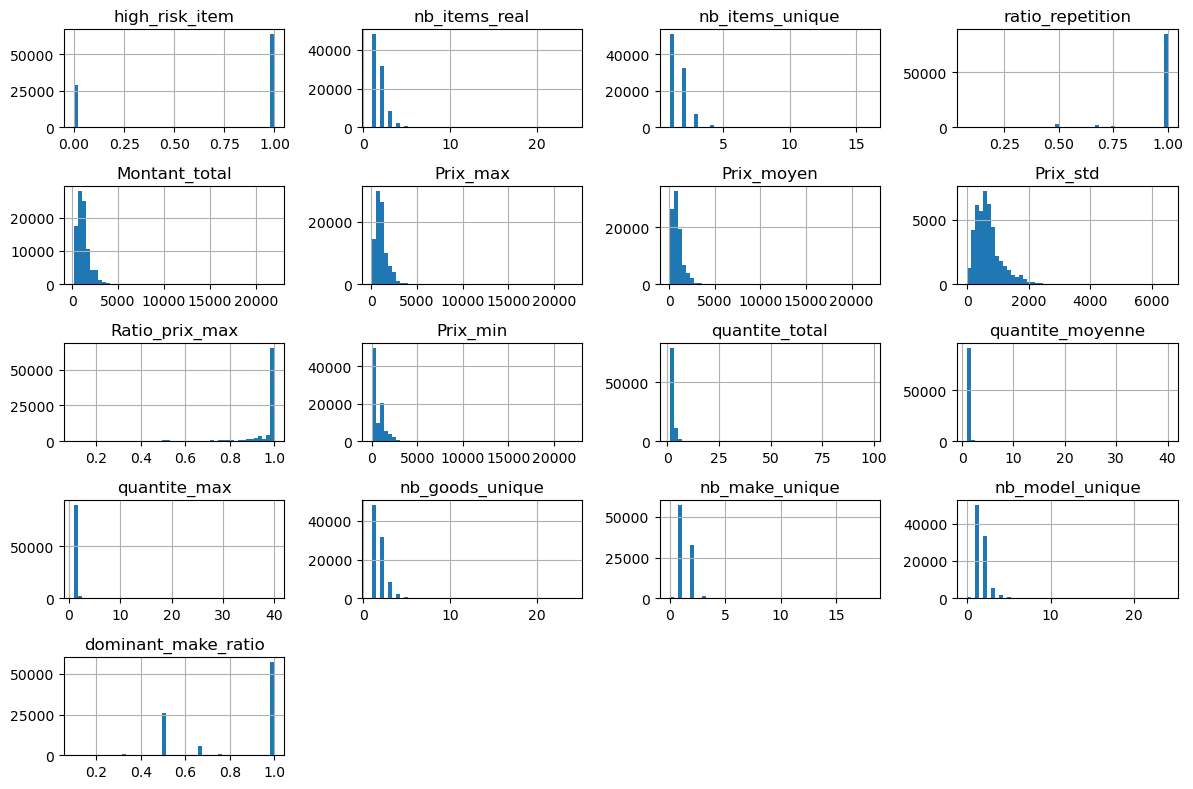

In [45]:
df_train.iloc[:,147:].hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

In [46]:
X.describe()

,high_risk_item,nb_items_real,nb_items_unique,ratio_repetition,Montant_total,Prix_max,Prix_moyen,Prix_std,Ratio_prix_max,Prix_min,quantite_total,quantite_moyenne,quantite_max,nb_goods_unique,nb_make_unique,nb_model_unique,dominant_make_ratio
count,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,44656.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92790.000000,92105.000000
mean,0.689719,1.760502,1.595862,0.961312,1234.759554,1140.466494,863.112562,691.606661,0.942662,628.109074,1.853864,1.029176,1.062259,1.758422,1.417567,1.637192,0.823455
std,0.462611,1.379435,0.852246,0.130476,771.484197,693.602559,640.697435,451.178318,0.129666,754.869218,1.981476,0.281946,0.493230,1.375367,0.700295,1.200480,0.232601
min,0.000000,1.000000,1.000000,0.080000,219.000000,79.000000,20.750000,0.000000,0.100000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.100000
25%,0.000000,1.000000,1.000000,1.000000,779.000000,719.000000,424.666667,383.251875,0.960000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000
50%,1.000000,1.000000,1.000000,1.000000,1099.000000,999.000000,703.833333,622.253967,1.000000,379.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,2.000000,1.000000,1499.000000,1379.000000,1117.000000,834.386002,1.000000,1049.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000
max,1.000000,24.000000,16.000000,1.000000,21995.000000,21995.000000,21995.000000,6503.968173,1.000000,21995.000000,98.000000,40.000000,40.000000,24.000000,18.000000,24.000000,1.000000


In [47]:
y.head(3)

,fraud_flag
0,0
1,0
2,0


# Création d'un jeu d'entrainement et de test

In [63]:
# importation des bibliothèques scikitlearn pour le Machine Learning
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import precision_recall_curve, average_precision_score,confusion_matrix
from sklearn.model_selection import StratifiedKFold

In [49]:
#Création jeu de test et d'entrainement avec répartition égale des cas de fraude (option = stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,
    random_state=42
)

In [50]:
X_train.describe()

,high_risk_item,nb_items_real,nb_items_unique,ratio_repetition,Montant_total,Prix_max,Prix_moyen,Prix_std,Ratio_prix_max,Prix_min,quantite_total,quantite_moyenne,quantite_max,nb_goods_unique,nb_make_unique,nb_model_unique,dominant_make_ratio
count,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,35797.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,74232.000000,73705.000000
mean,0.689500,1.762488,1.596239,0.960904,1236.022740,1141.176837,862.769164,692.628817,0.942473,626.950062,1.855803,1.028864,1.062480,1.760440,1.417259,1.639131,0.823687
std,0.462701,1.380614,0.850195,0.131145,770.902837,692.271420,638.451629,451.369632,0.129704,752.975482,1.973981,0.276541,0.491748,1.376498,0.698966,1.202884,0.232307
min,0.000000,1.000000,1.000000,0.080000,219.000000,79.000000,20.750000,0.000000,0.100000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.100000
25%,0.000000,1.000000,1.000000,1.000000,779.000000,719.000000,425.383333,383.251875,0.960000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000
50%,1.000000,1.000000,1.000000,1.000000,1099.000000,999.000000,704.583333,622.253967,1.000000,379.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,2.000000,1.000000,1499.000000,1379.000000,1117.000000,834.386002,1.000000,1045.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000
max,1.000000,24.000000,16.000000,1.000000,21995.000000,21995.000000,21995.000000,6503.968173,1.000000,21995.000000,98.000000,40.000000,40.000000,24.000000,18.000000,24.000000,1.000000


In [51]:
#Equilibrage Non-fraude / Fraude pour le modèle
scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1]

In [52]:
scale_pos_weight

69.36208530805688

In [53]:
# Passage sur 1 array des valeurs y
y_train_1d = y_train.squeeze()
y_test_1d  = y_test.squeeze()

In [54]:
#Définition des params du modèles
params = {
    "objective": "binary",
    "n_estimators": 2500,
    "learning_rate": 0.01,
    "num_leaves": 127,           
    "min_data_in_leaf": 150,     
    "feature_fraction": 0.7,
    "bagging_fraction": 0.7,
    "bagging_freq": 1,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "verbose":-1
}

model = lgb.LGBMClassifier(**params)

model.fit(X_train, y_train_1d)
#Calcule des proba
y_proba = model.predict_proba(X_test)[:,1]
#Affichage du PR AUC
print("PR AUC :", average_precision_score(y_test_1d, y_proba))

PR AUC : 0.1816315058691499


PR-AUC : 0.1816315058691499


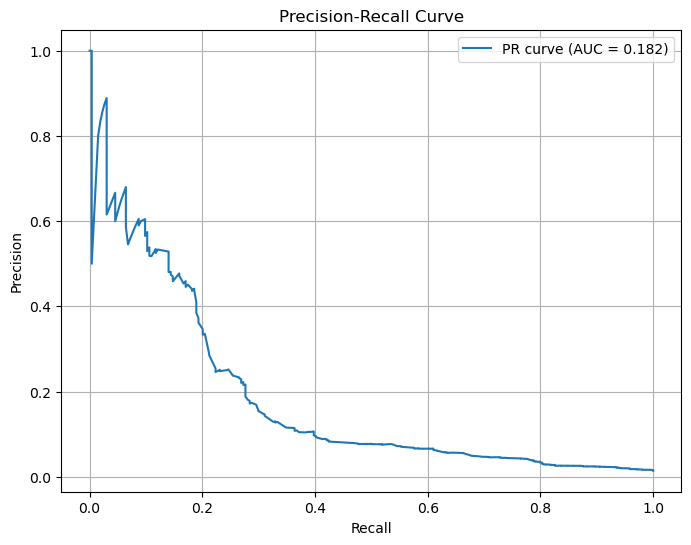

In [55]:
# Calcul des points de la courbe
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# PR-AUC
pr_auc = average_precision_score(y_test, y_proba)
print("PR-AUC :", pr_auc)

# Affichage du PR AUC
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
#Contrôle des Fraudes sur le modèles
arr = np.round(model.predict_proba(X_test)[:, 1], 0)
values, counts = np.unique(arr, return_counts=True)
print(values)
print(counts)

[0. 1.]
[14546  4012]


In [57]:
#Vérification si le modèle n'overfit pas entre le train et le test
pr_train = average_precision_score(y_train_1d, model.predict_proba(X_train.values)[:,1])
pr_test  = average_precision_score(y_test_1d,  model.predict_proba(X_test.values)[:,1])

print("PR-AUC train :", pr_train)
print("PR-AUC test  :", pr_test)

C:\Users\ramat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ramat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PR-AUC train : 0.36714294157234967
PR-AUC test  : 0.1816315058691499


In [58]:
# Réinitiation des index pour X et y pour le K-Fold
X = df_train.iloc[:, 147:].reset_index(drop=True)
y = df_train.iloc[:, 146].reset_index(drop=True)

# Initialisation du K-fold stratifié
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]

    model = lgb.LGBMClassifier(**params)

    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict_proba(X_valid_fold)[:, 1]
    pr_auc = average_precision_score(y_valid_fold, y_pred)
    scores.append(pr_auc)

    print(f"PR-AUC fold {fold+1}: {pr_auc:.4f}")

print("\nScores PR-AUC :", scores)
print("Moyenne :", np.mean(scores))
print("Écart-type :", np.std(scores))



--- Fold 1 ---
PR-AUC fold 1: 0.1700

--- Fold 2 ---
PR-AUC fold 2: 0.1473

--- Fold 3 ---
PR-AUC fold 3: 0.1630

--- Fold 4 ---
PR-AUC fold 4: 0.1753

--- Fold 5 ---
PR-AUC fold 5: 0.1342

Scores PR-AUC : [0.17000350082685947, 0.14729706430632306, 0.16304863461822572, 0.17525175579803, 0.13415720235062434]
Moyenne : 0.15795163158001252
Écart-type : 0.015167174795692325


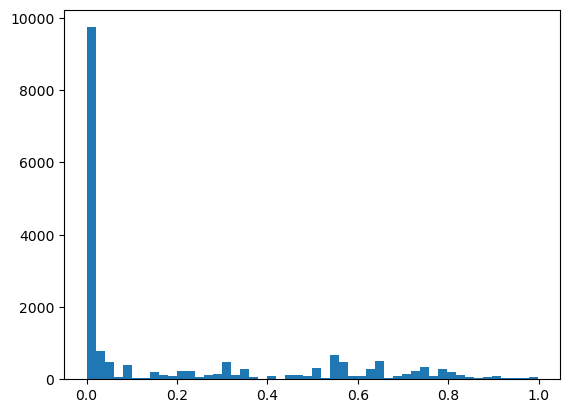

In [59]:
#Vérification de la distribution des valeurs
plt.hist(model.predict_proba(X_test)[:,1], bins=50)
plt.show()

In [60]:
from sklearn.metrics import precision_recall_curve

proba = model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test_1d, proba)


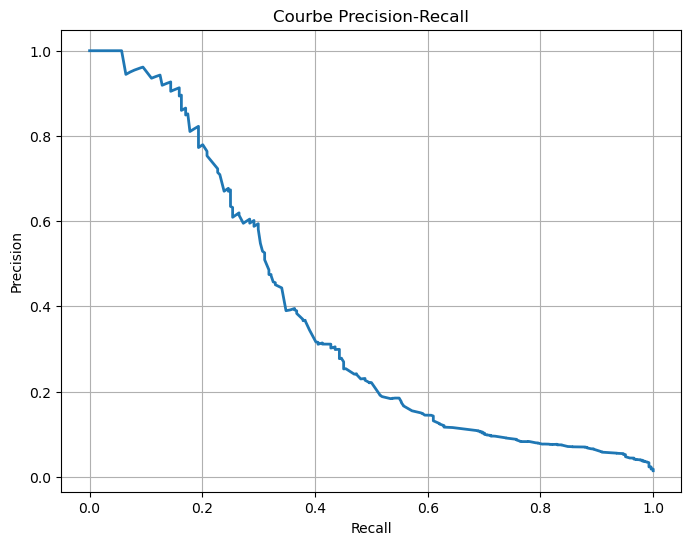

In [61]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_1d, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.grid(True)
plt.show()


In [68]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0, 1, 101)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test_1d, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
        best_precision = precision_score(y_test_1d, preds)
        best_recall = recall_score(y_test_1d, preds)

print(f"Meilleur seuil : {best_threshold:.3f}")
print(f"F1-score : {best_f1:.3f}")
print(f"Precision : {best_precision:.3f}")
print(f"Recall : {best_recall:.3f}")


Meilleur seuil : 0.930
F1-score : 0.395
Precision : 0.581
Recall : 0.299


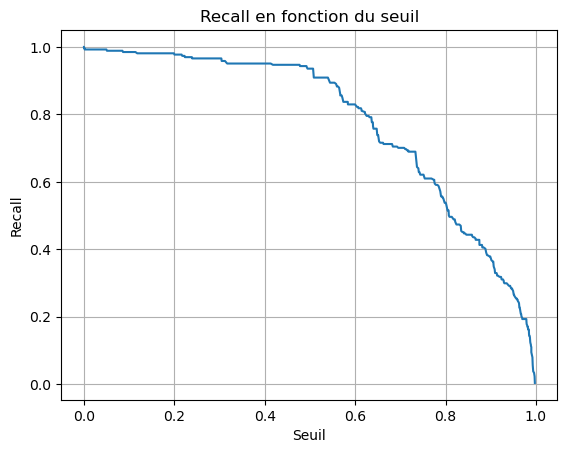

In [69]:
precision, recall, thresholds = precision_recall_curve(y_test_1d, y_proba)

plt.plot(thresholds, recall[:-1])
plt.xlabel("Seuil")
plt.ylabel("Recall")
plt.title("Recall en fonction du seuil")
plt.grid(True)
plt.show()


C:\Users\ramat\anaconda3\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


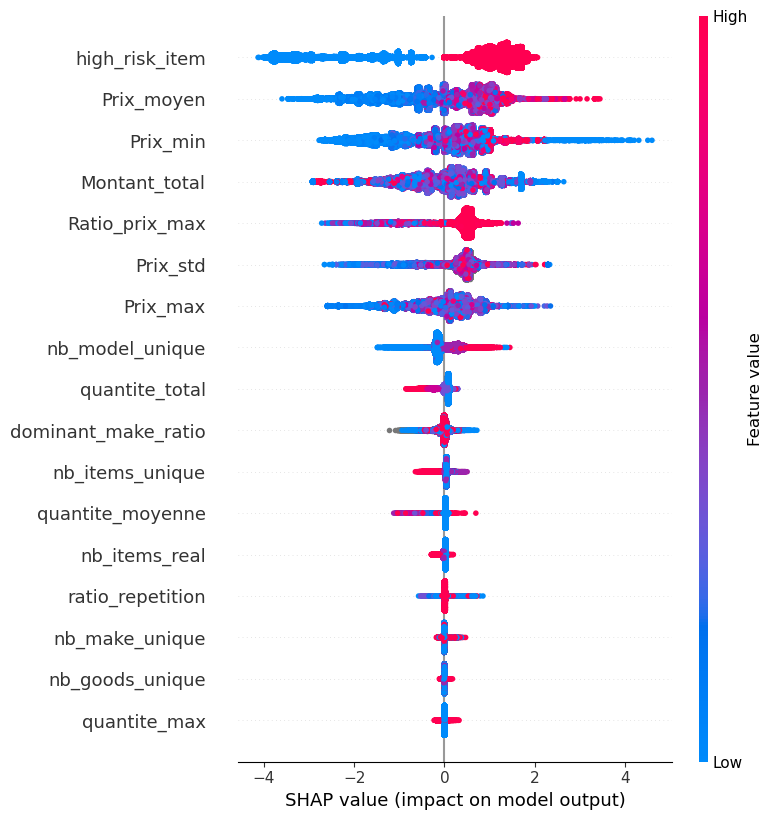

In [81]:
#Vérification des variables qui pèsent le plus dans le résultat
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

# Restitution du Challenge

In [70]:
#Chargement du jeu de test pour le challenge (Application des étapes précédentes)
df_train=pd.read_csv("X_test_8skS2ey.csv", low_memory=False)

In [71]:
#Ajout d'une colonne "fraud flag" pour correspondre au merge précédent
df_train["fraud_flag"]=0

In [72]:
#Attribution de la valeur risk
df_train["high_risk_item"] = (
    df_train[item_cols]
    .isin(high_risk_categories)
    .any(axis=1)
    .astype(int)
)

In [73]:
#Ajout des features
#1.1 - Calcule du nombre items réel présent par ligne
df_train['nb_items_real'] = df_train[item_cols].notna().sum(axis=1)
#1.2 - Identification du nombre d'items uniques par ligne
df_train["nb_items_unique"] = df_train[item_cols].apply(lambda row: row.dropna().nunique(), axis = 1)
#1.3 - Taux de répétion (exclusion des divisions par 0 ou sans valeur)
df_train["ratio_repetition"] = round((df_train["nb_items_unique"] / df_train['nb_items_real']).replace([np.inf, np.nan], 0),2)
#2.1 - Montant total du Panier par ligne
df_train["Montant_total"] = df_train[price_cols].sum(axis=1)
#2.2 - Prix maximum
df_train["Prix_max"] = df_train[price_cols].max(axis=1)
#2.3 - Prix Moyen
df_train["Prix_moyen"] = df_train[price_cols].mean(axis=1)
#2.4 - Dispersion des prix(Ecart Type)
df_train["Prix_std"] = df_train[price_cols].std(axis=1)
#2.5 - Ratio Prix max / Prix total
df_train["Ratio_prix_max"] = round(df_train["Prix_max"]/df_train["Montant_total"].replace([np.inf, np.nan], 0),2)
#2.6 - Prix minimum
df_train["Prix_min"] = df_train[price_cols].min(axis=1)
# 3.1 - Quantités totales
df_train["quantite_total"] = df_train[qty_cols].sum(axis=1)
# 3.2 - Quantités totales
df_train["quantite_moyenne"] = df_train[qty_cols].mean(axis=1)
# 3.3 - Quantités Max
df_train["quantite_max"] = df_train[qty_cols].max(axis=1)
# 4.1 - Diversité des catégories
df_train["nb_goods_unique"] = df_train[goods_cols].nunique(axis=1)
# 4.2 - Diversité des marques
df_train["nb_make_unique"] = df_train[make_cols].nunique(axis=1)
# 4.3 - Diversité des modèles
df_train["nb_model_unique"] = df_train[model_cols].nunique(axis=1)
# 4.4 - Dominance d'une marque
df_train["dominant_make_ratio"] = df_train[make_cols].apply(lambda row: row.value_counts(normalize=True).max(), axis=1)


In [74]:
#Création de X en ne conservant que les nouvelles features
X_challenge=df_train.iloc[:,147:]
#Création de y
y_challenge=df_train.iloc[:,146:147]

In [75]:
#Estimation des proba
y_pred_proba = model.predict_proba(X_challenge)[:, 1]

In [76]:
#Conversion en DataFrame
submission = pd.DataFrame(y_pred_proba,columns =['fraud_flag'])

In [77]:
df_train["fraud_flag"]=pd.DataFrame(y_pred_proba,columns =['fraud_flag'])

In [78]:
#Conservation des colonnes ID et Fraud_flag pour la restitution
submission = df_train[["ID","fraud_flag"]]

In [79]:
#Ajout d'un nom à l'index
submission.index.name = "Index"

In [80]:
#Exportation du DataFrame Challenge
submission.to_csv("submission.csv", index=True)